# DeepSeek-V4-Flash-0731 — 3-card PP3 vLLM decode and prefill

Measured **2026-08-30** on 3x NVIDIA CMP 170HX (SM80, 64 GB HBM2e each,
180 W per card). Single-stream greedy decode and prefill benchmark of the
official `deepseek-ai/DeepSeek-V4-Flash-0731` checkpoint (48 shards,
148 GB) on a full-source vLLM build, pipeline parallel 3
(`VLLM_PP_LAYER_PARTITION=15,15,13`), DSpark speculative decoding k=5.

Evidence source: `results/2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm/`
(README, RESULTS.md, sanitized launch script — the upstream evidence
repository contains no raw JSON or log files). Setup credit and base
patches: [allover326/deepseek-v4-cmp170hx](https://github.com/allover326/deepseek-v4-cmp170hx)
and [allover326/vllm-dsa-mtp-sm80](https://github.com/allover326/vllm-dsa-mtp-sm80)
(community-reported reference: ~78.8 tok/s aggregate decode on 4 cards).

Claim labels follow `AGENTS.md`: **measured** (this run's receipts),
**inferred** (stated capacity/config reasoning), **community-reported**
(external reference figures), **untested** (explicitly not exercised here).


In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True runs the same harness against a running OpenAI-compatible
# endpoint whose URL comes from an environment variable. Never hardcode an
# endpoint address in this notebook.
import os

EXPERIMENT = "2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
ENDPOINT_ENV_VAR = "DSV4_URL"  # set this env var before running with LIVE = True

print(f"experiment   : {EXPERIMENT}")
print(f"results_dir  : {RESULTS_DIR}")
print(f"LIVE         : {LIVE}")
if LIVE:
    endpoint = os.environ.get(ENDPOINT_ENV_VAR)
    if not endpoint:
        raise RuntimeError(f"LIVE=True but {ENDPOINT_ENV_VAR} is not set")
    print(f"endpoint     : from ${ENDPOINT_ENV_VAR} (not printed)")
else:
    print("endpoint     : n/a (replaying committed receipts)")


experiment   : 2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm
results_dir  : ../results/2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm
LIVE         : False
endpoint     : n/a (replaying committed receipts)


In [2]:
# --- Receipt loader, guard, and parser ----------------------------------
# LIVE = False: every number in this notebook is parsed out of the committed
# receipts in results/<experiment>/. Pins are literals that must each occur
# verbatim in a receipt (must_appear), so nothing can be quoted from memory.
import json
import os
import re


def load_text(name, results_dir=RESULTS_DIR):
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read()


def load_receipt(name, results_dir=RESULTS_DIR):
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return json.load(f)


RESULTS_MD = load_text("RESULTS.md")
README_MD = load_text("README.md")
LAUNCH_SH = load_text("launch-dsv4-3card.sh")
RECEIPTS = RESULTS_MD + "\n" + README_MD + "\n" + LAUNCH_SH


def must_appear(snippet):
    if snippet not in RECEIPTS:
        raise AssertionError(f"not found in receipts: {snippet!r}")


# Decode table (RESULTS.md): | prompt | tokens | elapsed s | tok/s |
decode_re = re.compile(
    r"^\|\s*(\*\*AGGREGATE\*\*|technical|open-prose|code)\s*\|\s*(\d+)\s*\|"
    r"\s*([\d.]+)\s*\|\s*\*{0,2}([\d.]+)\*{0,2}\s*\|",
    re.M,
)
decode = {}
for name, tokens, elapsed, tps in decode_re.findall(RESULTS_MD):
    decode[name.strip("*")] = {
        "tokens": int(tokens), "elapsed_s": float(elapsed), "tok_s": float(tps)
    }

# Prefill table (RESULTS.md): | real tokens | prefill tok/s |
prefill_re = re.compile(r"^\|\s*(\d+)\s*\|\s*\*{0,2}([\d.]+)\*{0,2}\s*\|", re.M)
prefill = [(int(tok), float(tps)) for tok, tps in prefill_re.findall(RESULTS_MD)]

acc_len = re.search(r"Mean acceptance length: ([\d.]+)-([\d.]+) \(k=(\d+)\)", RESULTS_MD)
draft_acc = re.search(r"Draft acceptance rate: ([\d.]+)-([\d.]+)%", RESULTS_MD)
per_pos = re.search(r"Per-position: ([\d./ ]+) \(typical\)", RESULTS_MD)
e2e = re.search(r"Short-prompt end-to-end decode \(prefill \+ 400 tok\): ([\d.]+) tok/s", RESULTS_MD)
ref = re.search(r"allover326 4-card config ~([\d.]+) tok/s", RESULTS_MD)
readme_agg = re.search(r"\*\*Result: ([\d.]+) tok/s aggregate decode\*\*", README_MD)
readme_prefill = re.search(r"up to \*\*([\d.]+) tok/s\s*prefill", README_MD)

assert {"technical", "open-prose", "code", "AGGREGATE"} <= set(decode), decode
assert len(prefill) == 4, prefill
assert acc_len and draft_acc and per_pos and e2e and ref and readme_agg and readme_prefill
# cross-check the two receipts against each other (headline vs tables)
assert float(readme_agg.group(1)) == decode["AGGREGATE"]["tok_s"]
assert float(readme_prefill.group(1)) == prefill[-1][1]
print("parsed: 4 decode rows, 4 prefill points, spec/e2e/reference lines; README headline matches tables")


parsed: 4 decode rows, 4 prefill points, spec/e2e/reference lines; README headline matches tables


In [3]:
# --- Helper: table renderer ----------------------------------------------
from IPython.display import display, Markdown


def render_table(headers, rows):
    """Render a list-of-lists as a Markdown table with the given headers.
    Every header carries its unit, e.g. 'Decode (tok/s)'."""
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


## 1. TL;DR

Single-stream decode and prefill of official DeepSeek-V4-Flash-0731 on
3x CMP 170HX, vLLM PP=3 + DSpark k=5, 180 W per card. **83.3 tok/s
aggregate decode** (1,200 tokens across three greedy 400-token prompts in
14.41 s wall) and **2965.0 tok/s prefill at 5,399 prompt tokens**. All
throughput figures are **measured** on this configuration. The 4-card
upstream reference (~78.8 tok/s aggregate decode) is **community-reported**
on a different topology and power budget; it is context, not a controlled
comparison.


In [4]:
# Values parsed from RESULTS.md in the receipt-loader cell above; the
# aggregate cross-check is derived arithmetic on receipt numbers, not a
# new measurement.
agg = decode["AGGREGATE"]
derived_agg = round(agg["tokens"] / agg["elapsed_s"], 1)
assert abs(derived_agg - agg["tok_s"]) <= 0.1

key_metrics = [
    ("Overall verdict", "PASS (measured): stable single-stream decode + prefill at the pinned config"),
    ("Aggregate decode (tok/s; 1,200 tok over 3 prompts, single stream)", agg["tok_s"]),
    ("Aggregate decode cross-check (tok/s; tokens / elapsed s, derived)", derived_agg),
    ("Decode, technical prompt (tok/s, 400 tok)", decode["technical"]["tok_s"]),
    ("Decode, open-prose prompt (tok/s, 400 tok)", decode["open-prose"]["tok_s"]),
    ("Decode, code prompt (tok/s, 400 tok)", decode["code"]["tok_s"]),
    ("Best prefill (tok/s at 5,399 prompt tokens, best of 2)", prefill[-1][1]),
    ("Short-prompt end-to-end decode (tok/s; prefill + 400 tok)", float(e2e.group(1))),
    ("Speculative decoding", f"DSpark k={acc_len.group(3)}; acceptance length "
     f"{acc_len.group(1)}-{acc_len.group(2)}; draft acc {draft_acc.group(1)}-{draft_acc.group(2)}%"),
    ("Power (W per card; locked, nvidia-smi verified)", 180),
    ("Cold boot to ready (min; 22 load + ~7 capture, measured)", "~30"),
]
render_table(["Metric (unit, denominator)", "Value"], key_metrics)


| Metric (unit, denominator) | Value |
|---|---|
| Overall verdict | PASS (measured): stable single-stream decode + prefill at the pinned config |
| Aggregate decode (tok/s; 1,200 tok over 3 prompts, single stream) | 83.3 |
| Aggregate decode cross-check (tok/s; tokens / elapsed s, derived) | 83.3 |
| Decode, technical prompt (tok/s, 400 tok) | 73.4 |
| Decode, open-prose prompt (tok/s, 400 tok) | 72.4 |
| Decode, code prompt (tok/s, 400 tok) | 116.6 |
| Best prefill (tok/s at 5,399 prompt tokens, best of 2) | 2965.0 |
| Short-prompt end-to-end decode (tok/s; prefill + 400 tok) | 129.2 |
| Speculative decoding | DSpark k=5; acceptance length 5.07-5.32; draft acc 81.3-86.4% |
| Power (W per card; locked, nvidia-smi verified) | 180 |
| Cold boot to ready (min; 22 load + ~7 capture, measured) | ~30 |

### Pins

Identity and configuration come from the receipt README, RESULTS.md, and
the sanitized launch script; every receipt-backed literal is asserted to
occur in the receipts by the loader cell. Server identity is what the
engine reported at startup (**measured**). Where a receipt records no value
(revision hash, image digest, runtime commit, torch/engine versions), the
absence is stated rather than guessed.


In [5]:
pins = [
    ("Model", "deepseek-ai/DeepSeek-V4-Flash-0731 (official)"),
    ("Revision hash", "not captured in receipts"),
    ("Safetensors shards / total size", "48 shards, 148 GB"),
    ("Runtime", "vLLM full CUDA source build, TORCH_CUDA_ARCH_LIST=8.0 (SM80); "
     "precompiled-image path fails, see appendix"),
    ("Image digest", "not captured in receipts (local source build; name masked in receipt)"),
    ("Fork lineage", "allover326/vllm-dsa-mtp-sm80 base + SM80 patches "
     "(5 files bind-mounted, see launch receipt)"),
    ("Torch / vLLM package version", "not captured in receipts"),
    ("Topology", "pipeline-parallel 3, VLLM_PP_LAYER_PARTITION=15,15,13 "
     "(last rank carries lm_head + DSpark drafter)"),
    ("Speculative decoding", "DSpark, num_speculative_tokens=5 (k=5)"),
    ("KV cache", "fp8, block-size 256, max-model-len 16384"),
    ("gpu-memory-utilization / batched tokens / max seqs", "0.95 / 2048 / 8"),
    ("Served name", "dsv4s"),
    ("Server identity (engine-reported)", "DeepseekV4ForCausalLM + DeepSeekV4MTPModel, "
     "model_type deepseek_v4"),
    ("Engine-reported architecture", "43 layers + 3 hash layers, 256 routed experts, "
     "expert_dtype fp4"),
    ("Hardware", "3x CMP 170HX, SM80, 64 GB HBM2e each, 180 W per card, PCIe Gen2 x4"),
    ("Sampling", "greedy, single stream (decode); best of 2 (prefill)"),
]
for snippet in [
    "deepseek-ai/DeepSeek-V4-Flash-0731", "48 shards, 148 GB",
    "TORCH_CUDA_ARCH_LIST=8.0", "VLLM_USE_PRECOMPILED", "vllm._C",
    "allover326/vllm-dsa-mtp-sm80", "VLLM_PP_LAYER_PARTITION=15,15,13",
    "num_speculative_tokens\":5", "kv-cache-dtype fp8", "block-size 256",
    "maxlen 16384", "--max-num-batched-tokens 2048", "--max-num-seqs 8",
    "--gpu-memory-utilization", "0.95", "dsv4s", "DeepseekV4ForCausalLM",
    "DeepSeekV4MTPModel", "deepseek_v4", "43 layers + 3 hash layers",
    "256 routed experts", "expert_dtype fp4", "PCIe Gen2 x4", "180 W",
    "best of 2", "greedy, single stream",
]:
    must_appear(snippet)
render_table(["Pin", "Value"], pins)
print("all receipt-backed pin literals verified against the receipts")


| Pin | Value |
|---|---|
| Model | deepseek-ai/DeepSeek-V4-Flash-0731 (official) |
| Revision hash | not captured in receipts |
| Safetensors shards / total size | 48 shards, 148 GB |
| Runtime | vLLM full CUDA source build, TORCH_CUDA_ARCH_LIST=8.0 (SM80); precompiled-image path fails, see appendix |
| Image digest | not captured in receipts (local source build; name masked in receipt) |
| Fork lineage | allover326/vllm-dsa-mtp-sm80 base + SM80 patches (5 files bind-mounted, see launch receipt) |
| Torch / vLLM package version | not captured in receipts |
| Topology | pipeline-parallel 3, VLLM_PP_LAYER_PARTITION=15,15,13 (last rank carries lm_head + DSpark drafter) |
| Speculative decoding | DSpark, num_speculative_tokens=5 (k=5) |
| KV cache | fp8, block-size 256, max-model-len 16384 |
| gpu-memory-utilization / batched tokens / max seqs | 0.95 / 2048 / 8 |
| Served name | dsv4s |
| Server identity (engine-reported) | DeepseekV4ForCausalLM + DeepSeekV4MTPModel, model_type deepseek_v4 |
| Engine-reported architecture | 43 layers + 3 hash layers, 256 routed experts, expert_dtype fp4 |
| Hardware | 3x CMP 170HX, SM80, 64 GB HBM2e each, 180 W per card, PCIe Gen2 x4 |
| Sampling | greedy, single stream (decode); best of 2 (prefill) |

all receipt-backed pin literals verified against the receipts


## 2. Visible results

Every table and the chart below are rendered from `RESULTS.md` in the
evidence bundle, parsed at runtime by the loader cell. Decode: one warm
pass per prompt, greedy, single stream, 400 completion tokens per prompt.
Prefill: best of 2 runs per fixture size. Token denominators are stated on
every column.


### 2.1 Decode — single stream, greedy, 400 completion tokens per prompt


In [6]:
order = ["technical", "open-prose", "code", "AGGREGATE"]
rows = [
    (k, decode[k]["tokens"], decode[k]["elapsed_s"], decode[k]["tok_s"])
    for k in order
]
render_table(
    ["Prompt", "Completion tokens (count)", "Elapsed wall time (s)",
     "Decode throughput (tok/s, single stream)"],
    rows,
)
print(f"Reference (community-reported): allover326 4-card config ~{ref.group(1)} tok/s "
      "aggregate decode — different topology and higher total power.")
print(f"Derived cross-check: {agg['tokens']} tok / {agg['elapsed_s']} s = "
      f"{agg['tokens'] / agg['elapsed_s']:.1f} tok/s (matches the receipt's aggregate).")


| Prompt | Completion tokens (count) | Elapsed wall time (s) | Decode throughput (tok/s, single stream) |
|---|---|---|---|
| technical | 400 | 5.45 | 73.4 |
| open-prose | 400 | 5.52 | 72.4 |
| code | 400 | 3.43 | 116.6 |
| AGGREGATE | 1200 | 14.41 | 83.3 |

Reference (community-reported): allover326 4-card config ~78.8 tok/s aggregate decode — different topology and higher total power.
Derived cross-check: 1200 tok / 14.41 s = 83.3 tok/s (matches the receipt's aggregate).


### 2.2 Prefill — uncached, best of 2 runs per fixture


In [7]:
render_table(
    ["Prompt tokens (count, tokenizer)", "Prefill throughput (tok/s, best of 2 runs)"],
    prefill,
)
print(f"Best prefill: {prefill[-1][1]} tok/s at {prefill[-1][0]} prompt tokens (~5.4K context).")
print(f"Short-prompt end-to-end decode (prefill + 400 tok): {e2e.group(1)} tok/s.")


| Prompt tokens (count, tokenizer) | Prefill throughput (tok/s, best of 2 runs) |
|---|---|
| 784 | 1667.3 |
| 1553 | 2081.6 |
| 3091 | 2626.9 |
| 5399 | 2965.0 |

Best prefill: 2965.0 tok/s at 5399 prompt tokens (~5.4K context).
Short-prompt end-to-end decode (prefill + 400 tok): 129.2 tok/s.


### 2.3 Speculative decoding — engine-reported metrics


In [8]:
spec_rows = [
    ("Mean acceptance length (tokens per step, engine metrics, k=5)",
     f"{acc_len.group(1)} - {acc_len.group(2)}"),
    ("Draft acceptance rate (%, engine metrics)",
     f"{draft_acc.group(1)} - {draft_acc.group(2)}"),
    ("Per-position acceptance (typical, positions 1-5)", per_pos.group(1).strip()),
]
render_table(["Engine metric (unit)", "Value"], spec_rows)


| Engine metric (unit) | Value |
|---|---|
| Mean acceptance length (tokens per step, engine metrics, k=5) | 5.07 - 5.32 |
| Draft acceptance rate (%, engine metrics) | 81.3 - 86.4 |
| Per-position acceptance (typical, positions 1-5) | 1.000 / 0.900 / 0.767 / 0.767 / 0.633 |

### 2.4 Chart

Left: decode throughput by prompt (tokens/second, single stream, 400
completion tokens each) with the community-reported 4-card reference as a
dashed line. Right: prefill throughput against prompt-token count
(tokens/second, best of 2). Exported to
`assets/charts/2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm.{png,svg}`.


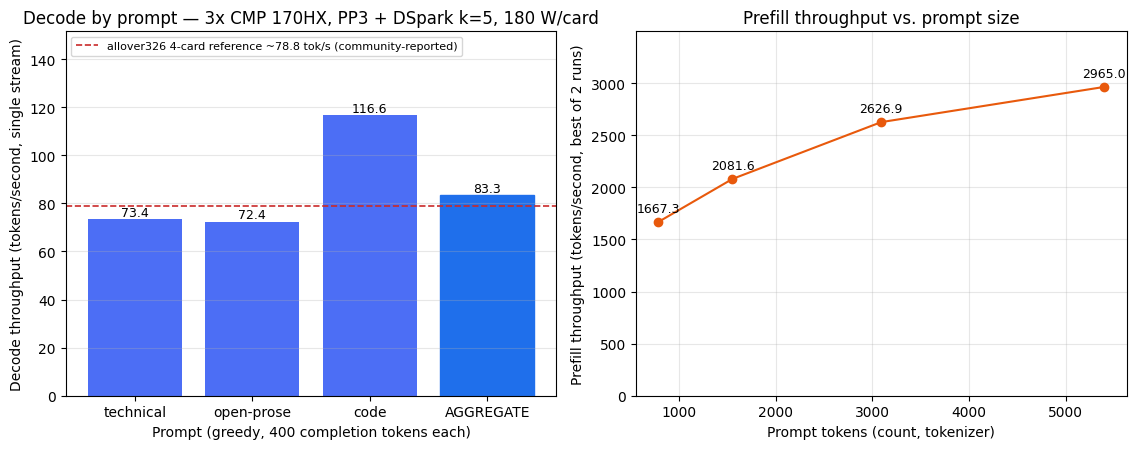

saved: assets/charts/2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm.{png,svg}


In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))

names = ["technical", "open-prose", "code", "AGGREGATE"]
vals = [decode[n]["tok_s"] for n in names]
bars = ax1.bar(range(len(names)), vals, color="#4c6ef5")
bars[-1].set_color("#1f6feb")
ax1.axhline(float(ref.group(1)), color="#c92a2a", linestyle="--", linewidth=1.2,
            label=f"allover326 4-card reference ~{ref.group(1)} tok/s (community-reported)")
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v}", ha="center", fontsize=9)
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names)
ax1.set_ylabel("Decode throughput (tokens/second, single stream)")
ax1.set_xlabel("Prompt (greedy, 400 completion tokens each)")
ax1.set_title("Decode by prompt — 3x CMP 170HX, PP3 + DSpark k=5, 180 W/card")
ax1.set_ylim(0, max(vals) * 1.3)
ax1.grid(True, axis="y", alpha=0.3)
ax1.legend(loc="upper left", fontsize=8)

toks = [t for t, _ in prefill]
tps = [p for _, p in prefill]
ax2.plot(toks, tps, marker="o", color="#e8590c")
for t, p in zip(toks, tps):
    ax2.annotate(f"{p}", xy=(t, p), xytext=(0, 7),
                 textcoords="offset points", ha="center", fontsize=9)
ax2.set_ylabel("Prefill throughput (tokens/second, best of 2 runs)")
ax2.set_xlabel("Prompt tokens (count, tokenizer)")
ax2.set_title("Prefill throughput vs. prompt size")
ax2.set_ylim(0, max(tps) * 1.18)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm.png",
            dpi=150, bbox_inches="tight")
fig.savefig("../assets/charts/2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm.svg",
            bbox_inches="tight")
plt.show()
print("saved: assets/charts/2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm.{png,svg}")


## 3. Reproduce

**Hardware.** 3x NVIDIA CMP 170HX (SM80 / compute capability 8.0, 64 GB
HBM2e each, no FP4 tensor cores), PCIe Gen2 x4, power locked at 180 W per
card (nvidia-smi verified before and during runs), forced airflow. Weights
live on shared model storage (`<model-storage>/`; an 8.4 TB NFS volume in
the receipt).

**Weights.** `deepseek-ai/DeepSeek-V4-Flash-0731`, 48 shards, 148 GB.
The receipts do not record a revision hash — the exact revision used here
is **not captured in receipts**; pin your own snapshot hash before serving.

**Runtime.** No prebuilt image reproduces this recipe: the precompiled
path (`VLLM_USE_PRECOMPILED`) silently ships without `vllm._C` and fails
at graph capture (see appendix). A full CUDA source build with
`TORCH_CUDA_ARCH_LIST=8.0` is required, with the five SM80 patch files
bind-mounted from the fork working tree (see the launch receipt below).

**Launch** (sanitized record from
`results/2026-08-30-deepseek-v4-flash-0731-3card-pp3-vllm/launch-dsv4-3card.sh`;
names/paths masked, so it will not run as-is):


In [10]:
print("```bash")
print(LAUNCH_SH.rstrip())
print("```")
print()
print("Serve + health-check invocation used for the measured run (receipt README):")
print("    DSV4_MAXLEN=16384 DSV4_GPU_UTIL=0.95 bash launch-dsv4-3card.sh")
print("    curl http://127.0.0.1:8098/health")


```bash
#!/usr/bin/env bash
# allover326/deepseek-v4-cmp170hx best config, adapted to 3 cards per README:
# PP=3, VLLM_PP_LAYER_PARTITION=15,15,13, DSpark speculative on, 180 W caps.
# Sanitized record: container/image names and storage paths are masked with
# <...> placeholders; this script will not run as-is under bash.
set -euo pipefail
IMG="${DSV4_IMG:-<image>}"
R="<workdir>/repos/dsv4-vllm/vllm"
MODEL="<model-storage>/deepseek-ai/DeepSeek-V4-Flash-0731"
MAXLEN="${DSV4_MAXLEN:-32768}"
ROW_CHUNK="${DSV4_ROW_CHUNK:-64}"
GPU_UTIL="${DSV4_GPU_UTIL:-0.85}"
SPEC='--speculative-config {"method":"dspark","num_speculative_tokens":5}'

docker stop -t 60 <container> >/dev/null 2>&1 || true
docker rm <container> >/dev/null 2>&1 || true

MOUNTS=""
for f in config/speculative.py \
         v1/worker/gpu/pp_utils.py \
         v1/worker/gpu/model_runner.py \
         v1/worker/gpu/spec_decode/dspark/utils.py \
         model_executor/layers/sparse_attn_indexer.py; do
  MOUNTS="$MOUNTS -v $R/$f:/v

**Bench command.** The harness scripts (`bench_decode3.py`,
`bench_prefill.py`) come from the upstream allover326 repositories and are
**not included in this bundle**; per the receipt README:

```bash
python3 bench_decode3.py run
python3 bench_prefill.py run 42
```

**Expected boot time.** ~30 minutes cold on NFS-backed storage: 22 minutes
shard load plus ~7 minutes CUDA graph capture (**measured**, receipt README
and RESULTS.md).

**Functional gate notes.** Greedy sampling, single stream, 400 completion
tokens per decode prompt; prefill figures are best of 2 runs;
`gpu-memory-utilization` must be 0.95 on 3 cards — 0.85 and 0.93 fail KV
allocation on the lm_head-heavy last rank (**measured** negative result,
appendix).


## 4. Appendix

<details>
<summary>Preflight, safety, failure history, and publication notes (click to expand)</summary>

### 4.1 Preflight and safety

Per `AGENTS.md`: forced airflow before load, stop at 80 °C core / 85 °C
memory, stop on Xid, GPU disappearance, or memory errors. What the
receipts record: power caps locked at 180 W per card and verified with
`nvidia-smi` before and during the runs (**measured**). The receipts
contain **no temperature telemetry, no Xid/ECC scan output, and no
storage-condition snapshot** for this experiment — those checks are not
captured in receipts and are stated here rather than claimed.


In [11]:
preflight = [
    ("Power limit per card (W)", "180, locked; nvidia-smi verified before and during runs"),
    ("Forced airflow before load", "house rule; not separately recorded in receipts"),
    ("Core temp stop condition (C)", 80),
    ("Memory temp stop condition (C)", 85),
    ("Max core / memory temp observed (C)", "not captured in receipts"),
    ("Xid / ECC events", "not captured in receipts (no scan output committed)"),
    ("Weights storage", "read-only bind mount from <model-storage> over NFS"),
]
render_table(["Check", "Value (from receipts where present)"], preflight)


| Check | Value (from receipts where present) |
|---|---|
| Power limit per card (W) | 180, locked; nvidia-smi verified before and during runs |
| Forced airflow before load | house rule; not separately recorded in receipts |
| Core temp stop condition (C) | 80 |
| Memory temp stop condition (C) | 85 |
| Max core / memory temp observed (C) | not captured in receipts |
| Xid / ECC events | not captured in receipts (no scan output committed) |
| Weights storage | read-only bind mount from <model-storage> over NFS |

### 4.2 What does not work

Three dead ends are recorded in the receipt README, preserved here:

1. **Precompiled vLLM image (`VLLM_USE_PRECOMPILED`) — measured failure.**
   Silently ships without `vllm._C`, so
   `fused_deepseek_v4_qnorm_rope_kv_rope_quant_insert_out` fails at graph
   capture. Fix: full CUDA source build with `TORCH_CUDA_ARCH_LIST=8.0` —
   the same warning documented in the upstream allover326
   `Dockerfile.fullbuild`.
2. **`gpu-memory-utilization` below 0.95 on 3 cards — measured failure.**
   KV allocation fails on rank 2 (the lm_head-heavy last rank): 51.8 GiB
   weights + activations + CUDA graphs leave ~9 GiB; at 0.95 it fits with
   7.7 GiB of KV cache. Fix: run at 0.95.
3. **NVFP4 recipes (GLM-5.3-Flash, Qwen3.8-Flash-Next DGX Spark kits) —
   inferred, not attempted.** CMP 170HX is SM80 with no FP4 path, and those
   checkpoints (~181 GiB) do not fit 3x64 GB regardless. Recorded as a dead
   end without a run.

Approach evolution: the recipe is the allover326 4-card best config adapted
down to 3 cards (layer partition 15,15,13; last rank carries lm_head +
DSpark drafter). The 3-card aggregate (83.3 tok/s, measured) lands ~4.5
tok/s above the 4-card reference (~78.8 tok/s, community-reported) at lower
total power — context only, not a controlled A/B.

### 4.3 Publication and limitations

**What this shows (measured).** Official DeepSeek-V4-Flash-0731 served on
3x CMP 170HX at 180 W/card with vLLM PP=3 + DSpark k=5: 83.3 tok/s
aggregate single-stream decode (1,200 tokens / 14.41 s across technical,
prose, and code prompts), up to 2965.0 tok/s prefill at 5,399 prompt
tokens, and 129.2 tok/s short-prompt end-to-end decode.

**What this does not show.**

- **No concurrency ladder.** Every decode figure is single-stream
  (max-num-seqs 8 configured, one stream measured). Higher concurrency is
  untested in this bundle.
- **Prefill is best of 2 runs**; per-rep raw samples and warmup detail are
  not in the receipts.
- **No thermal/Xid/ECC telemetry committed** for this experiment (see
  4.1), so thermal headroom cannot be audited from this bundle.
- **Missing pins**: exact model revision hash, image digest, runtime
  commit, and torch/engine versions are not captured in receipts.
- The ~78.8 tok/s 4-card comparison is **community-reported** on a
  different topology and power budget.

**Links.**

- Upstream evidence repository:
  [PixelML/DeepSeek-V4-Flash-0731-CMP-170HX](https://github.com/PixelML/DeepSeek-V4-Flash-0731-CMP-170HX)
  (README, RESULTS.md, launch script — the three files copied into this
  bundle; no raw JSON/log files exist upstream).
- Setup credit and base patches:
  [allover326/deepseek-v4-cmp170hx](https://github.com/allover326/deepseek-v4-cmp170hx),
  [allover326/vllm-dsa-mtp-sm80](https://github.com/allover326/vllm-dsa-mtp-sm80).

</details>
